<h1 align="center" id="top"><u>Pokemon classification</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ</u></h3>

# Table of Contents
***
1. [Import](#import)
2. [Processing](#processing)
3. [Evaluation](#evaluation)
    - [Visual](#visual)
    - [Deep Learning](#deep-learning)

## Import
***

In [1]:
from pathlib import Path

from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from torch.utils.data import DataLoader

from background import remove_background
from config import AugmentationMethod, BackgroundMethod, ExtractMethod
from display import show_confusion_matrix, show_image
from models import CNNModel, CNNTransferModel, ViTImageModel
from pipeline import (
    evaluate_all_methods,
    evaluate_all_methods_dl,
    split_dataset,
    split_dataset_torch,
)
from preprocessing import preprocessing
from utils import build_dataframe, load_image

Let's now load the dataset using pandas (mapping the images path with their respective pokemon)

In [ ]:
data_dir = Path.cwd().resolve().parents[0] / "data" / "fanart-dataset"

fanart_df = build_dataframe(data_dir)

print("\nTotal images:", len(fanart_df))
print("Total Pokemon:", fanart_df["pokemon"].nunique())
print("\n20 most present pokemon:")
print(fanart_df["pokemon"].value_counts().head(20))


Total images: 10710
Total Pokémon: 887

20 most present pokemon:
pokemon
gengar       84
greninja     67
umbreon      67
suicune      65
bulbasaur    64
leafeon      63
sylveon      63
eevee        62
rayquaza     62
garchomp     61
arcanine     60
lugia        60
vaporeon     59
sceptile     58
blastoise    57
scizor       57
zoroark      57
giratina     55
gardevoir    54
mewtwo       54
Name: count, dtype: int64


Now let's filter a bit our dataset so that we only keep pokemons with a sufficient number of images

In [ ]:
MIN_PER_CLASS = 15
counts = fanart_df["pokemon"].value_counts()
keep = counts[counts >= MIN_PER_CLASS].index
fanart_df_filtered = fanart_df[fanart_df["pokemon"].isin(keep)].reset_index(drop=True)

print("After filter:")
print("Total images:", len(fanart_df_filtered))
print("Total Pokemon:", fanart_df_filtered["pokemon"].nunique())
print(fanart_df_filtered["pokemon"].value_counts().head(10))

After filter:
Total images: 6957
Total Pokémon: 230
pokemon
gengar       84
greninja     67
umbreon      67
suicune      65
bulbasaur    64
leafeon      63
sylveon      63
eevee        62
rayquaza     62
garchomp     61
Name: count, dtype: int64


In [4]:
fanart_df_filtered

,path,pokemon
0,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
1,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
2,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
3,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
4,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
...,...,...
6952,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua
6953,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua
6954,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua
6955,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua


Let's encode now the label using sklearn's LabelEncoder and split the dataframe into a dataset of path and labels and keep only the 10 most represented classes to avoid having too much classes with too few images

In [5]:
top10 = fanart_df_filtered["pokemon"].value_counts().head(10).index
fanart_df_filtered = (
    fanart_df_filtered[fanart_df_filtered["pokemon"].isin(top10)].copy().reset_index(drop=True)
)
print(fanart_df_filtered["pokemon"].value_counts())

pokemon
gengar       84
greninja     67
umbreon      67
suicune      65
bulbasaur    64
leafeon      63
sylveon      63
eevee        62
rayquaza     62
garchomp     61
Name: count, dtype: int64


In [6]:
dataset = fanart_df_filtered["path"]
label = fanart_df_filtered["pokemon"]

label_encoder = LabelEncoder()
label = label_encoder.fit_transform(label)

## Processing
***

Now that we have our dataset, let's test some transformations on the images to test our functions and see how they work. First of all, let's load an image and see how it looks like

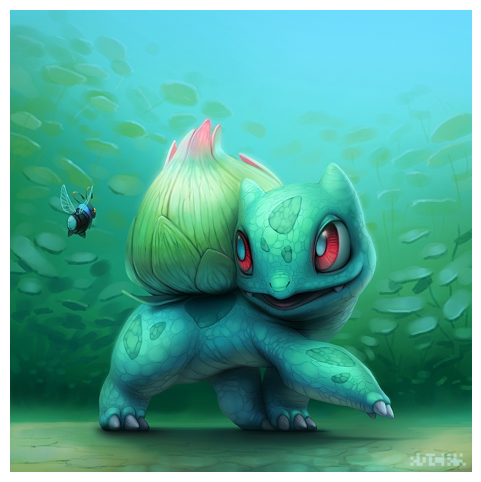

In [7]:
im_path = Path(dataset[3])
im = load_image(im_path)
show_image(im)

Now we apply our preprocessing pipeline to enhance the image by boosting its local contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization). We convert the image to the Lab color space, apply CLAHE only on the luminance (L) channel to reveal details in dark/bright regions while limiting noise amplification, then merge the channels back. 

This preprocessing give us a clearer image with better-defined textures and edges, which can help the classification

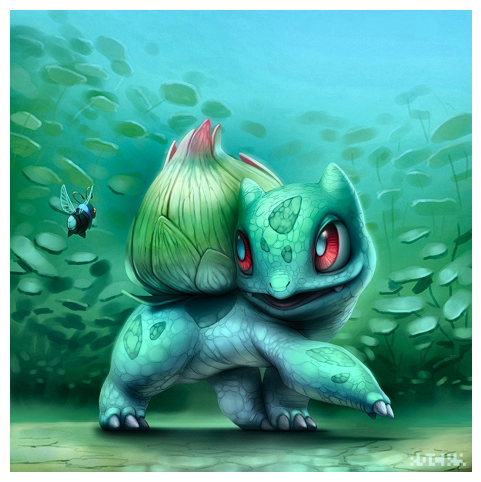

In [8]:
new_im = preprocessing(im)
show_image(new_im)

Now we attempt to segment the Pokemon from the background using the GrabCut algorithm. We initialize GrabCut with a rectangle covering most of the image (assuming the main object is centered), then iteratively refine the foreground and background models. 

The resulting mask is converted into a binary foreground mask, followed by a cleaning involving a morphological closing and opening operations to remove noise and fill small holes. Finally, we keep only the largest connected component to isolate the main object and apply the mask to remove the background, resulting in an image where in general the Pokemon is segmented from its background

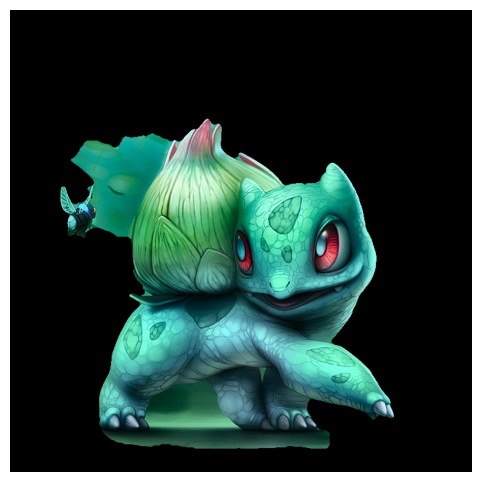

In [9]:
only_pokemon = remove_background(new_im, im_path, method=BackgroundMethod.GRABCUT)
show_image(only_pokemon)

## Evaluation
***

### Visual
***

The goal of this part is to evaluate an image classification pipeline using a Bag of Visual Words (BoVW) approach combined with feature descriptors. Unlike deep learning methods, this approach relies entirely on classical computer vision techniques and traditional machine learning.

The objective here is to assess how well a non-deep learning pipeline can perform on a challenging and imperfect Pokemon dataset that contains variability in backgrounds, style, poses, colors, and image quality, making it a realistic and a non-trivial classification problem.

Now that preprocessing, background removal, and descriptor extraction are in place, we move on to building the train/test pipeline. We first perform a stratified train-test split to preserve class balance, then apply data augmentation only on the training set (e.g., one horizontal flip and two rotations per image). Next, we extract local descriptors (SIFT/ORB) for every image in both splits and using the training descriptors only, we learn a visual vocabulary with K-Means. Finally, we encode each image as a fixed-length BoVW histogram.

In [10]:
X_train, X_test, y_train, y_test = split_dataset(
    dataset,
    label,
    AugmentationMethod.TRUE,
    ExtractMethod.SIFT,
    BackgroundMethod.GRABCUT,
)

[INFO] : Dataset split done ! (train=526, test=132)
[INFO] : Dataset augmentation done ! (train=2104, test=132)


Extracting descriptors for train:   0%|                    | 0/2104 

Extracting descriptors for test:   0%|                    | 0/132 

[INFO] : Starting BoVW training...
[INFO] : BoVW training finished ! 
[INFO] : Starting BoVW encoding...
[INFO] : BoVW encoding done ! 


Now that the dataset has already been split into training and testing sets, we train a simple baseline model to evaluate the raw performance of our pipeline. To do this we will use a simple SVM classifier as a baseline

In [11]:
clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

              precision    recall  f1-score   support

   bulbasaur       0.40      0.31      0.35        13
       eevee       0.31      0.42      0.36        12
    garchomp       0.50      0.25      0.33        12
      gengar       0.59      0.59      0.59        17
    greninja       0.56      0.77      0.65        13
     leafeon       0.50      0.31      0.38        13
    rayquaza       0.53      0.67      0.59        12
     suicune       0.70      0.54      0.61        13
     sylveon       0.50      0.69      0.58        13
     umbreon       0.50      0.50      0.50        14

    accuracy                           0.51       132
   macro avg       0.51      0.50      0.49       132
weighted avg       0.51      0.51      0.50       132



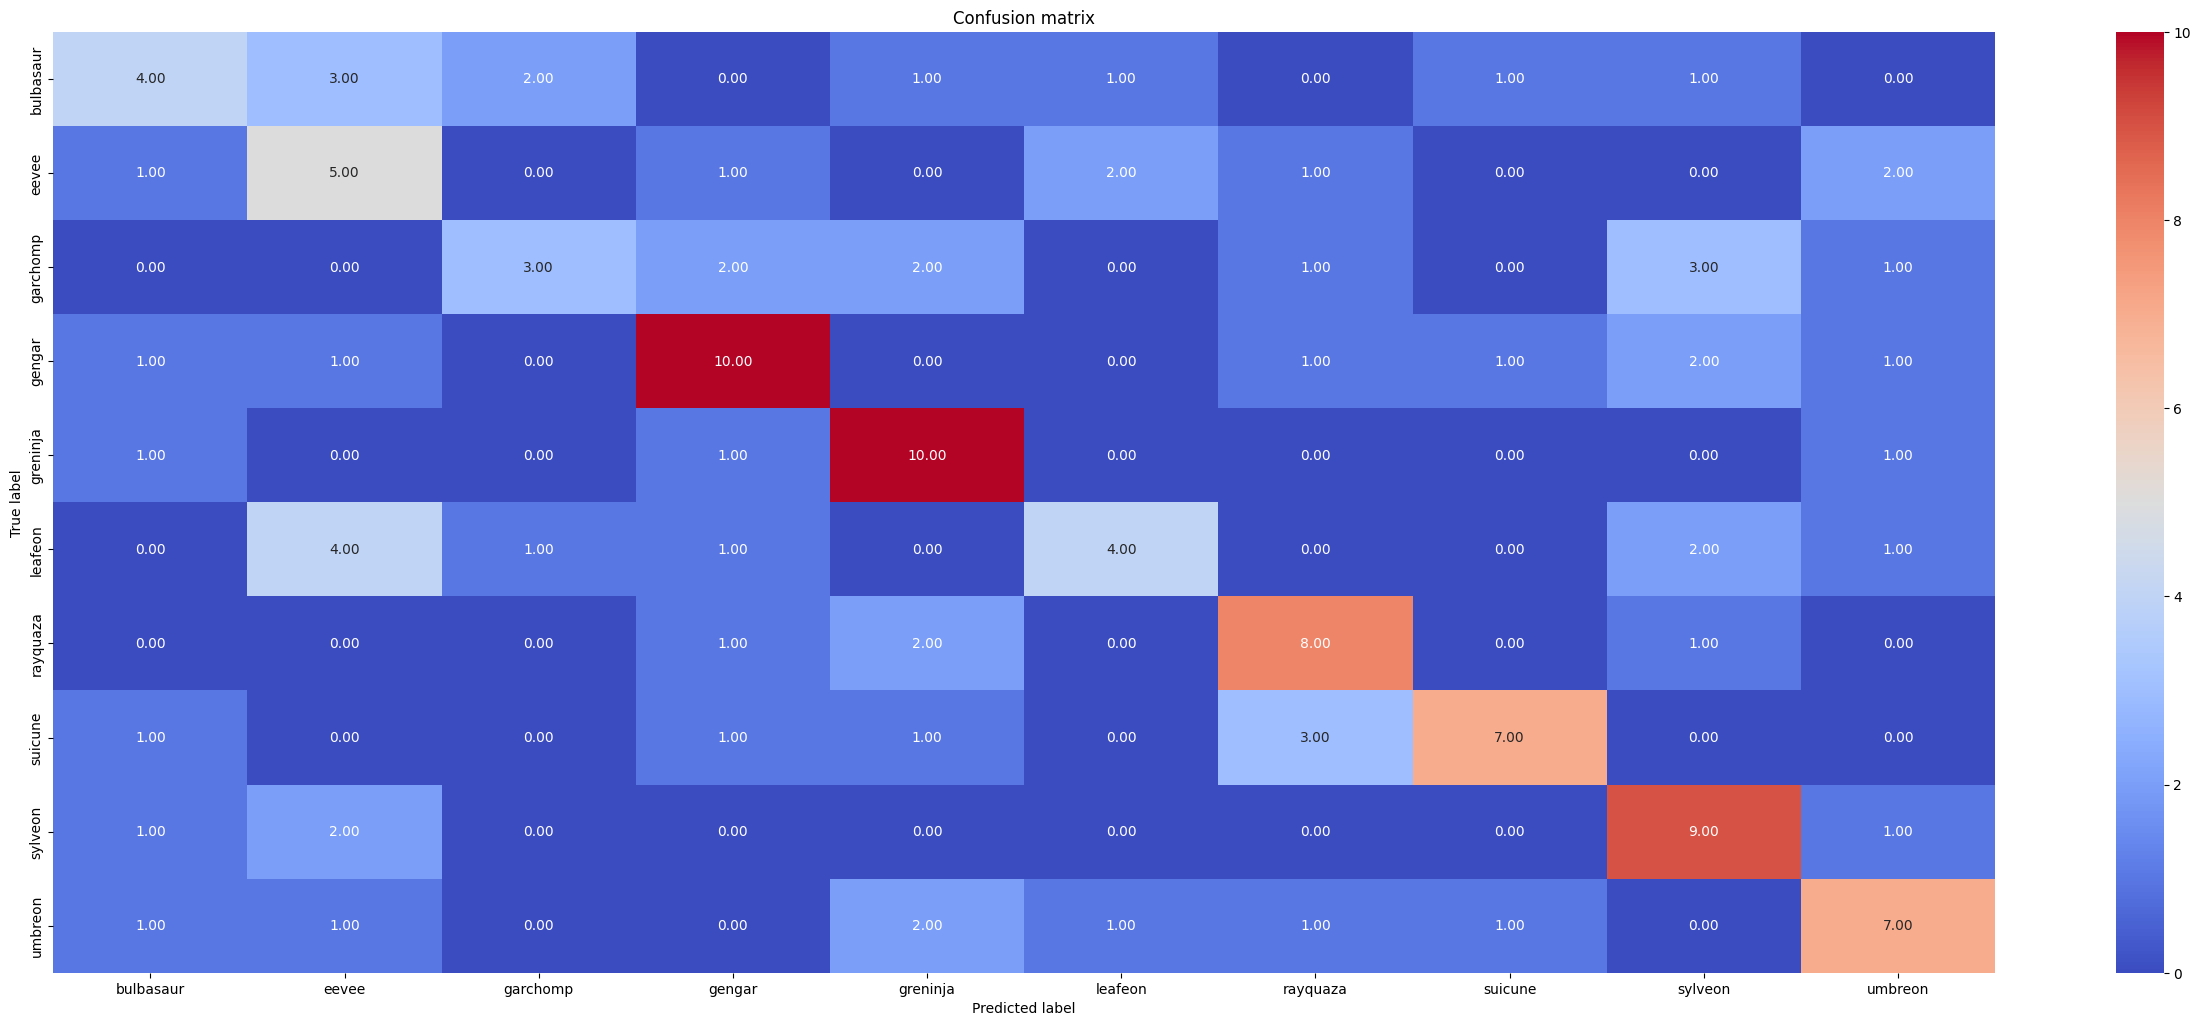

In [12]:
show_confusion_matrix(y_test, y_pred, label_encoder.classes_, "Confusion matrix")

As we can observe, the overall performance is relatively low, which is expected given the difficulty of the dataset, which includes high visual variability and some labeling inconsistencies.

We will now evaluate all possible combinations of parameters using the same final classifier in order to determine the optimal configuration for our pipeline. The objective is to systematically compare feature extraction methods, background processing strategies, and augmentation settings to identify the combination that yields the best overall performance

In [13]:
models = [
    (LinearSVC, {"C": 1.0, "random_state": 42}),
]
results = evaluate_all_methods(dataset, label, label_encoder, models)
results

Evaluation:   0%|                              | 0/8 

Extracting descriptors for train:   0%|                    | 0/526 

Extracting descriptors for test:   0%|                    | 0/132 

Extracting descriptors for train:   0%|                    | 0/526 

Extracting descriptors for test:   0%|                    | 0/132 

...

Extracting descriptors for train:   0%|                    | 0/2104 

Extracting descriptors for test:   0%|                    | 0/132 

Extracting descriptors for train:   0%|                    | 0/2104 

Extracting descriptors for test:   0%|                    | 0/132 

,model,augmentation_method,extract_method,background_method,accuracy,precision_macro,recall_macro,f1_macro,classification_report,train_time_sec
0,LinearSVC,NONE,SIFT,NONE,0.484848,0.486099,0.483527,0.472743,precision recall f1-score ...,0.128067
1,LinearSVC,NONE,SIFT,GRABCUT,0.484848,0.459061,0.475097,0.458381,precision recall f1-score ...,0.097476
2,LinearSVC,NONE,ORB,NONE,0.507576,0.525777,0.508506,0.498398,precision recall f1-score ...,0.115888
3,LinearSVC,NONE,ORB,GRABCUT,0.409091,0.410211,0.404110,0.401588,precision recall f1-score ...,0.106794
4,LinearSVC,TRUE,SIFT,NONE,0.484848,0.506125,0.484809,0.487780,precision recall f1-score ...,0.569841
5,LinearSVC,TRUE,SIFT,GRABCUT,0.469697,0.480938,0.468784,0.469323,precision recall f1-score ...,0.517748
6,LinearSVC,TRUE,ORB,NONE,0.469697,0.484813,0.468784,0.466210,precision recall f1-score ...,0.619069
7,LinearSVC,TRUE,ORB,GRABCUT,0.424242,0.428521,0.418875,0.412485,precision recall f1-score ...,0.544343


Using our evaluation pipeline, we can observe that, overall, data augmentation tended to introduce additional noise rather than improving performance. We also see that background segmentation did not lead to better feature extraction, likely because the segmentation masks are not perfectly accurate and sometimes contain errors. 

As a result, the best performance is achieved when using the original dataset without augmentation or background removal, and relying solely on ORB for feature extraction. Now, let us examine the classification report for this best-performing configuration

In [15]:
print(results.loc[2, "classification_report"])

              precision    recall  f1-score   support

   bulbasaur       0.44      0.54      0.48        13
       eevee       0.78      0.58      0.67        12
    garchomp       0.50      0.17      0.25        12
      gengar       0.50      0.47      0.48        17
    greninja       0.53      0.77      0.62        13
     leafeon       0.50      0.31      0.38        13
    rayquaza       0.47      0.67      0.55        12
     suicune       0.70      0.54      0.61        13
     sylveon       0.47      0.62      0.53        13
     umbreon       0.38      0.43      0.40        14

    accuracy                           0.51       132
   macro avg       0.53      0.51      0.50       132
weighted avg       0.52      0.51      0.50       132



As we can see in this report, the model performs reasonably well on several classes but struggles significantly on others. For example, classes such as Eevee and Greninja achieve higher scores, suggesting that their visual patterns are more distinctive and easier to capture with the BoVW + ORB representation. 

In contrast, classes like Garchomp and Leafeon show much lower recall, meaning that many of their samples are misclassified. This likely comes from strong visual similarities with other Pokemon (shape, colors, textures) and from the limitations of local descriptors when the dataset contains large variations in style, pose, lighting, and background. 

Overall, these results highlight that the pipeline can capture discriminative features for certain Pokemon, but its performance remains inconsistent across classes, which is expected given the complexity and imperfections of the dataset

### Deep Learning
***

Now let's move on to the deep learning part. Since our fanart images come in different sizes, we first need to standardize them by resizing all inputs to a fixed resolution. We choose 224×224, as it is a widely used input size for image classification and is the default setting for many ImageNet pre-trained backbones. In addition, we will evaluate whether our previous preprocessing strategy-data augmentation and background segmentation-also benefits these models.

First of all let's split our dataset into training, validation and testing sets

In [10]:
train_dataset, val_dataset, test_dataset = split_dataset_torch(
    dataset,
    label,
    AugmentationMethod.TRUE,
    BackgroundMethod.GRABCUT,
)

[INFO] : Dataset split done ! (train=460, val=66, test=132)
[INFO] : Dataset augmentation done ! (train=1840, val=66, test=132)
[INFO] : Creating PyTorch dataset...
[INFO] : PyTorch train/val/test datasets ready !


Now we can create the corrersponding PyTorch dataloader for each dataset for the training of our deep learning models

In [11]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Now that the data part is finished, we can move on to the training of our deep learning models. We will start with a a basic CNN 

In [12]:
model = CNNModel(num_classes=10)
model.fit(train_loader=train_loader, val_loader=val_loader, epochs=10)

y_pred = model.predict(test_loader)

y_true = []
for _, y_batch in test_loader:
    y_true.extend(y_batch.numpy())

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

Training Epochs:   0%|                    | 0/10 

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

...

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

              precision    recall  f1-score   support

   bulbasaur       0.56      0.69      0.62        13
       eevee       0.64      0.58      0.61        12
    garchomp       0.29      0.42      0.34        12
      gengar       0.86      0.71      0.77        17
    greninja       0.67      0.92      0.77        13
     leafeon       0.50      0.38      0.43        13
    rayquaza       0.73      0.67      0.70        12
     suicune       0.90      0.69      0.78        13
     sylveon       0.69      0.85      0.76        13
     umbreon       0.78      0.50      0.61        14

    accuracy                           0.64       132
   macro avg       0.66      0.64      0.64       132
weighted avg       0.67      0.64      0.65       132



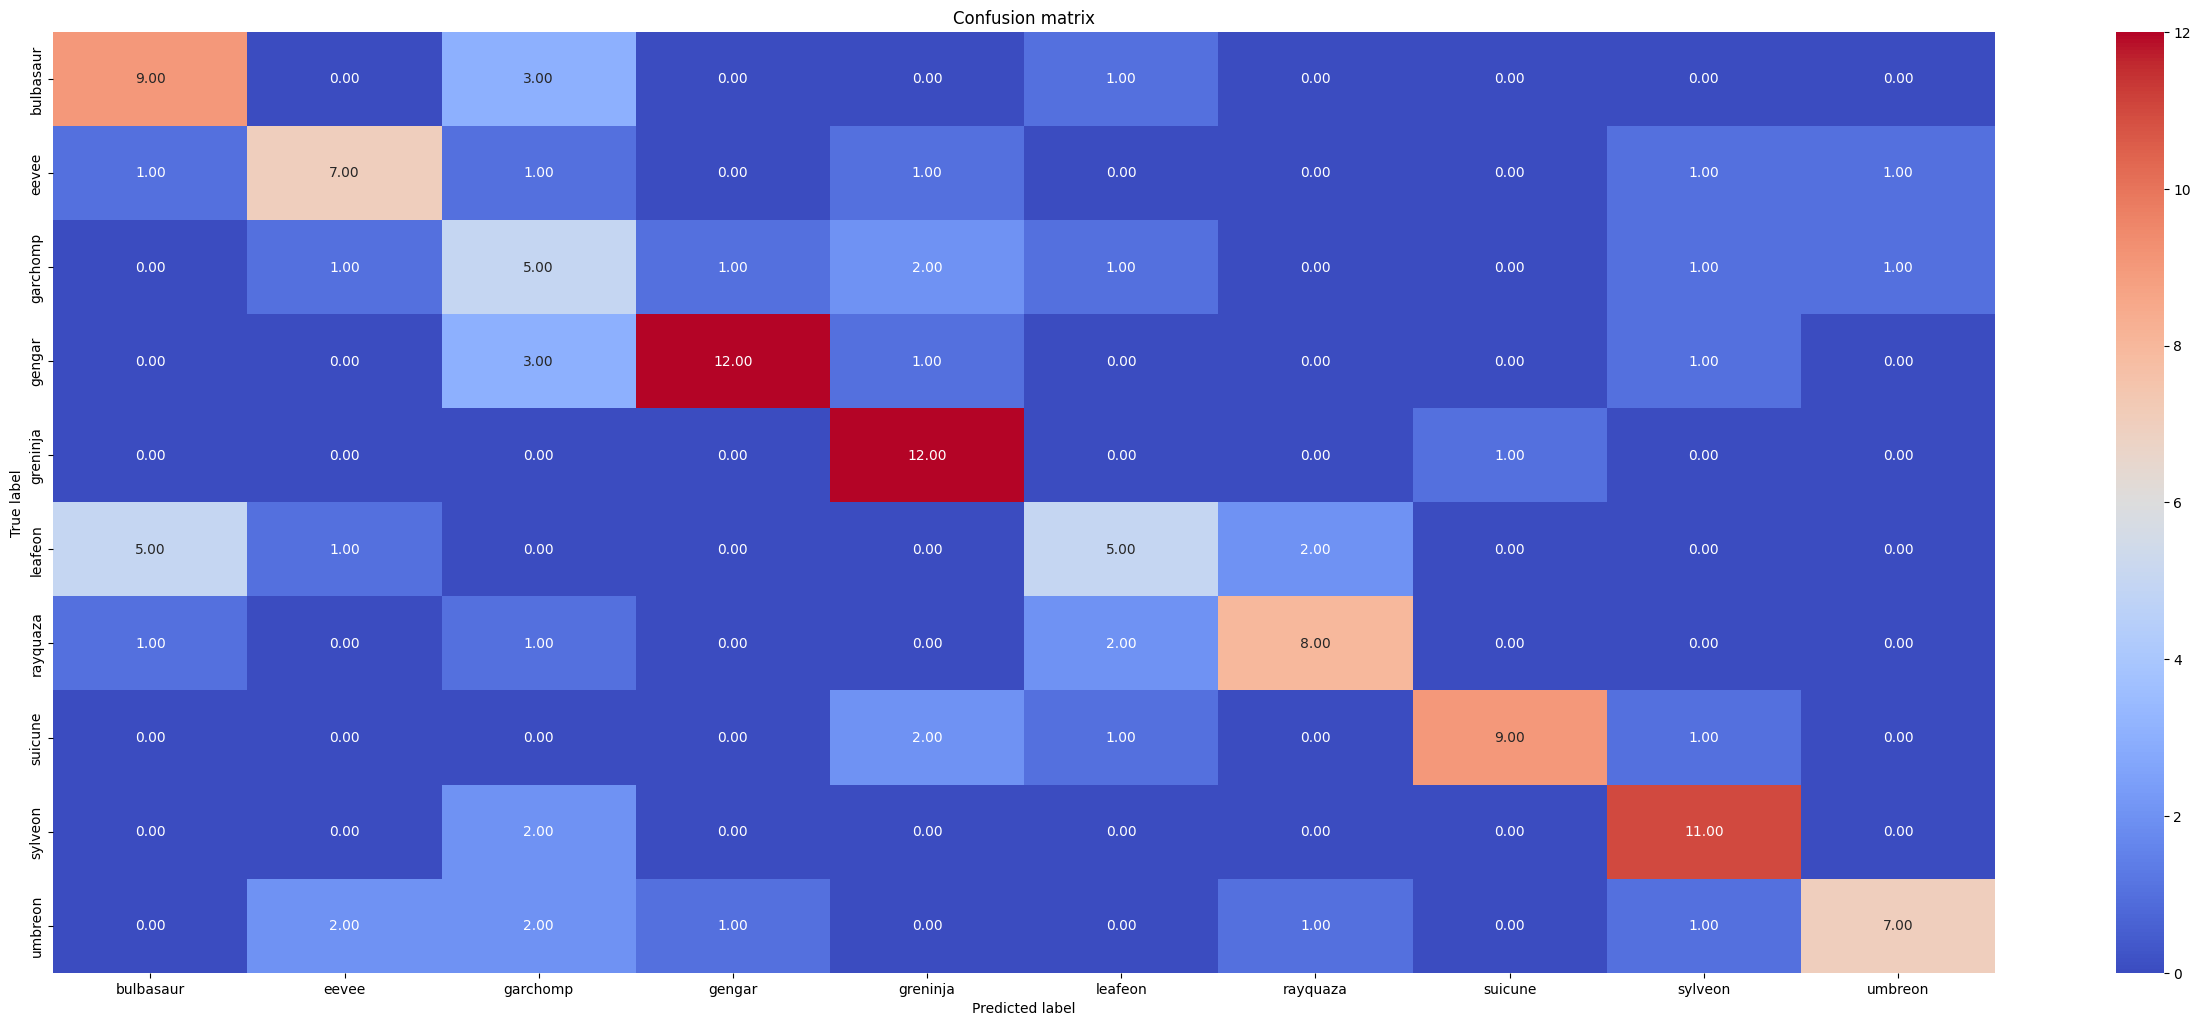

In [13]:
show_confusion_matrix(y_true, y_pred, label_encoder.classes_, "Confusion matrix")

As we can see, the CNN models run correctly, but the improvement over a fully hand-crafted visual pipeline remains relatively low, around a 10% accuracy gain so far. 

The next step is to run a more systematic comparison by evaluating several architectures and all combinations of data augmentation and background segmentation, in order to identify the configuration that generalizes best on this fanart dataset. Concretely, we will benchmark three families of models, a baseline CNN trained from scratch, a CNN with transfer learning using a pre-trained ResNet-18, and a Vision Transformer (ViT-B/16)

In [11]:
models = [
    (CNNModel, {"num_classes": 10}),
    (CNNTransferModel, {"num_classes": 10}),
    (ViTImageModel, {"num_classes": 10}),
]

df_results = evaluate_all_methods_dl(
    dataset,
    label,
    label_encoder,
    models,
    early_stopping_patience=None,
)
df_results

Evaluation:   0%|                              | 0/12 

Training Epochs:   0%|                    | 0/10 

Training Batches:   0%|                    | 0/15 

Training Batches:   0%|                    | 0/15 

Training Batches:   0%|                    | 0/15 

...

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

Training Batches:   0%|                    | 0/58 

,model,augmentation_method,background_method,accuracy,precision_macro,recall_macro,f1_macro,classification_report,train_time_sec
0,CNNModel,NONE,NONE,0.628788,0.628327,0.625603,0.613113,precision recall f1-score ...,243.269809
1,CNNModel,NONE,GRABCUT,0.628788,0.637918,0.628787,0.621171,precision recall f1-score ...,457.107674
2,CNNModel,TRUE,NONE,0.590909,0.621360,0.594150,0.587074,precision recall f1-score ...,1014.862546
3,CNNModel,TRUE,GRABCUT,0.628788,0.649631,0.623427,0.625975,precision recall f1-score ...,1353.650245
4,CNNTransferModel,NONE,NONE,0.780303,0.790655,0.782423,0.780392,precision recall f1-score ...,232.591861
5,CNNTransferModel,NONE,GRABCUT,0.742424,0.753847,0.742793,0.736723,precision recall f1-score ...,296.926224
6,CNNTransferModel,TRUE,NONE,0.787879,0.799020,0.785854,0.782086,precision recall f1-score ...,1007.461767
7,CNNTransferModel,TRUE,GRABCUT,0.787879,0.789631,0.790665,0.784963,precision recall f1-score ...,1269.975708
8,ViTImageModel,NONE,NONE,0.833333,0.848782,0.834734,0.838736,precision recall f1-score ...,312.014934
9,ViTImageModel,NONE,GRABCUT,0.772727,0.784253,0.775372,0.770884,precision recall f1-score ...,374.070243


Using our evaluation pipeline, we can clearly see that model choice has the biggest impact on performance. The CNN trained from scratch reaches around 0.63 accuracy, while the ResNet-18 with transfer learning significantly improves the results to about 0.79 and the best performance is achieved with ViT-B/16, which reaches up to 0.85 accuracy.

We can also observe that background segmentation with GrabCut does not improve performance and that in most cases, it slightly decreases accuracy, likely because the segmentation masks are not perfectly accurate and may remove useful visual information. Moreover Regarding data augmentation, it provides a small improvement for the pretrained models (ResNet and ViT), but it also considerably increases training time.

Overall, the best configuration is ViT-B/16 with data augmentation and without background removal. We will now examine the classification report of this best-performing model to better understand which classes are well predicted and where the remaining errors occur

In [13]:
print(df_results.loc[10, "classification_report"])

              precision    recall  f1-score   support

   bulbasaur       0.75      0.69      0.72        13
       eevee       0.85      0.92      0.88        12
    garchomp       0.90      0.75      0.82        12
      gengar       0.93      0.76      0.84        17
    greninja       0.81      1.00      0.90        13
     leafeon       0.60      0.69      0.64        13
    rayquaza       0.86      1.00      0.92        12
     suicune       1.00      0.85      0.92        13
     sylveon       1.00      1.00      1.00        13
     umbreon       0.86      0.86      0.86        14

    accuracy                           0.85       132
   macro avg       0.86      0.85      0.85       132
weighted avg       0.86      0.85      0.85       132



As shown in the classification report, the model performs well overall, reaching 0.85 accuracy and with a 0.85 macro F1-score. Several classes are classified very reliably, for example, Sylveon is perfectly recognized (1.00 precision/recall/F1), and Rayquaza and Greninja have 1.00 recall, meaning the model almost never misses them. This suggests these Pokemon have very distinctive visual features that remain consistent across different fanart styles.

However, some classes are harder to classify like Leafeon that has the lowest scores (0.60 precision, 0.69 recall, 0.64 F1), indicating more confusion with other Pokemon, probably because its appearance is less distinctive or overlaps visually with similar classes. Overall, the model generalizes well, but the remaining errors likely come from fanart variability (style, pose, lighting, background) and visual similarities between certain Pokemon.